In [ ]:
import pandas as pd
url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


# **Ingreso total por cada tienda**

In [11]:
ingreso_tienda1 = tienda['Precio'].dropna().sum()
ingreso_tienda2 = tienda2['Precio'].dropna().sum()
ingreso_tienda3 = tienda3['Precio'].dropna().sum()
ingreso_tienda4 = tienda4['Precio'].dropna().sum()
resultados = pd.DataFrame({
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Ingreso Total': [ingreso_tienda1, ingreso_tienda2, ingreso_tienda3, ingreso_tienda4]
})


resultados['Ingreso Total'] = resultados['Ingreso Total'].apply(lambda x: f"${x:,.0f}")


print("INGRESOS TOTALES POR TIENDA")
print(resultados.to_string(index=False))
print(f"\n Ingreso total combinado: ${sum([ingreso_tienda1, ingreso_tienda2, ingreso_tienda3, ingreso_tienda4]):,.0f}")

INGRESOS TOTALES POR TIENDA
  Tienda  Ingreso Total
Tienda 1 $1,150,880,400
Tienda 2 $1,116,343,500
Tienda 3 $1,098,019,600
Tienda 4 $1,038,375,700

 Ingreso total combinado: $4,403,619,200


# **Ventas por categoría**

In [15]:
tienda['Tienda'] = 'Tienda 1'
tienda2['Tienda'] = 'Tienda 2'
tienda3['Tienda'] = 'Tienda 3'
tienda4['Tienda'] = 'Tienda 4'

df = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

ventas_categoria = df.groupby(['Tienda', 'Categoría del Producto']).size().reset_index(name='Cantidad_Ventas')
ventas_categoria = ventas_categoria.sort_values(['Tienda', 'Cantidad_Ventas'], ascending=[True, False])

print("=== Ventas por Categoría en cada Tienda ===")
print(ventas_categoria.to_string(index=False))

print("\n=== Top 3 Categorías más Populares por Tienda ===")
top_categorias = ventas_categoria.groupby('Tienda').head(3)
print(top_categorias.to_string(index=False))

=== Ventas por Categoría en cada Tienda ===
  Tienda  Categoría del Producto  Cantidad_Ventas
Tienda 1                 Muebles              465
Tienda 1            Electrónicos              448
Tienda 1                Juguetes              324
Tienda 1       Electrodomésticos              312
Tienda 1    Deportes y diversión              284
Tienda 1  Instrumentos musicales              182
Tienda 1                  Libros              173
Tienda 1 Artículos para el hogar              171
Tienda 2                 Muebles              442
Tienda 2            Electrónicos              422
Tienda 2                Juguetes              313
Tienda 2       Electrodomésticos              305
Tienda 2    Deportes y diversión              275
Tienda 2  Instrumentos musicales              224
Tienda 2                  Libros              197
Tienda 2 Artículos para el hogar              181
Tienda 3                 Muebles              499
Tienda 3            Electrónicos              451
Tienda

# **Valoración media por tienda**

In [16]:
df = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)
valoracion_media = df.groupby('Tienda')['Calificación'].mean().reset_index(name='Calificación_Promedio')
valoracion_media = valoracion_media.sort_values('Calificación_Promedio', ascending=False)
print(valoracion_media.to_string(index=False))

  Tienda  Calificación_Promedio
Tienda 3               4.048326
Tienda 2               4.037304
Tienda 4               3.995759
Tienda 1               3.976685


# **Productos más vendidos y menos vendidos**

In [21]:
df = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)
productos_ventas = df.groupby(['Tienda', 'Producto']).size().reset_index(name='Cantidad_Ventas')
mas_vendidos = productos_ventas.loc[productos_ventas.groupby('Tienda')['Cantidad_Ventas'].idxmax()]
menos_vendidos = productos_ventas.loc[productos_ventas.groupby('Tienda')['Cantidad_Ventas'].idxmin()]
print("=== PRODUCTOS MÁS VENDIDOS POR TIENDA ===")
print(mas_vendidos[['Tienda', 'Producto', 'Cantidad_Ventas']].to_string(index=False))
print("\n=== PRODUCTOS MENOS VENDIDOS POR TIENDA ===")
print(menos_vendidos[['Tienda', 'Producto', 'Cantidad_Ventas']].to_string(index=False))

=== PRODUCTOS MÁS VENDIDOS POR TIENDA ===
  Tienda                  Producto  Cantidad_Ventas
Tienda 1                   Armario               60
Tienda 2 Iniciando en programación               65
Tienda 3             Kit de bancas               57
Tienda 4                  Cama box               62

=== PRODUCTOS MENOS VENDIDOS POR TIENDA ===
  Tienda                  Producto  Cantidad_Ventas
Tienda 1 Auriculares con micrófono               33
Tienda 2             Juego de mesa               32
Tienda 3   Bloques de construcción               35
Tienda 4        Guitarra eléctrica               33


# **Valor del envío promedio por tienda**

In [22]:
df = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)
envio_promedio = df.groupby('Tienda')['Costo de envío'].mean().reset_index(name='Envio_Promedio')
envio_promedio = envio_promedio.sort_values('Envio_Promedio', ascending=False)
print(envio_promedio.to_string(index=False))

  Tienda  Envio_Promedio
Tienda 1    26018.609580
Tienda 2    25216.235693
Tienda 3    24805.680373
Tienda 4    23459.457167


# **Visualización**

# Generando gráfico

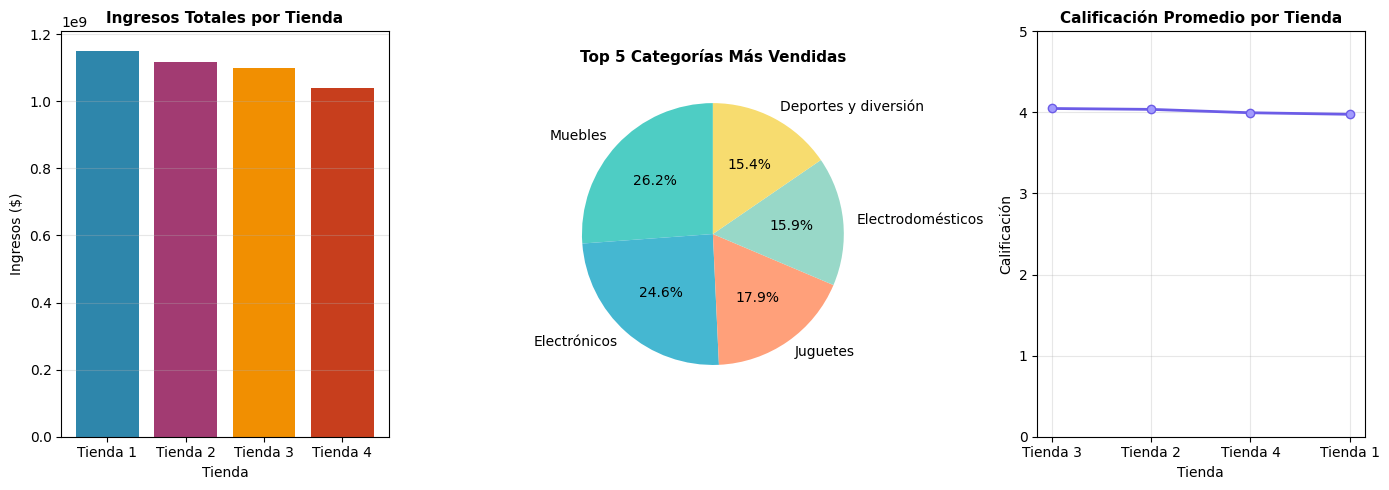

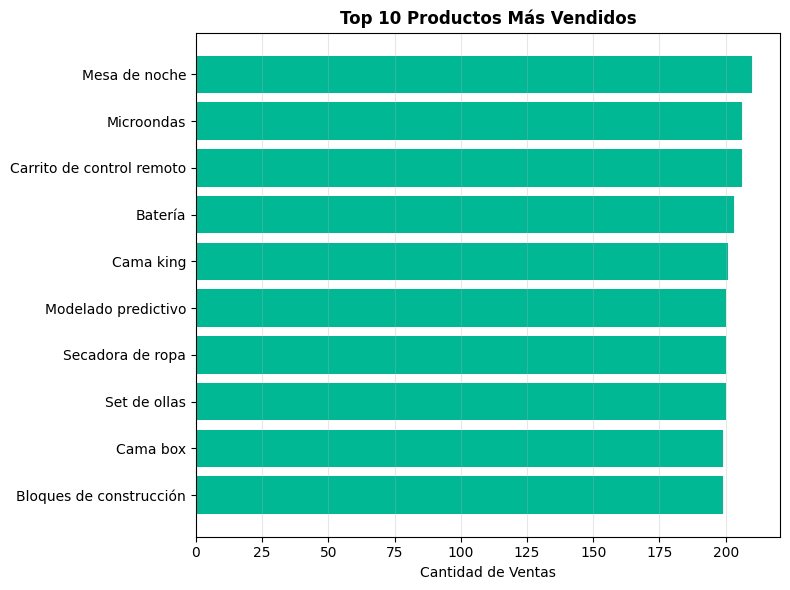

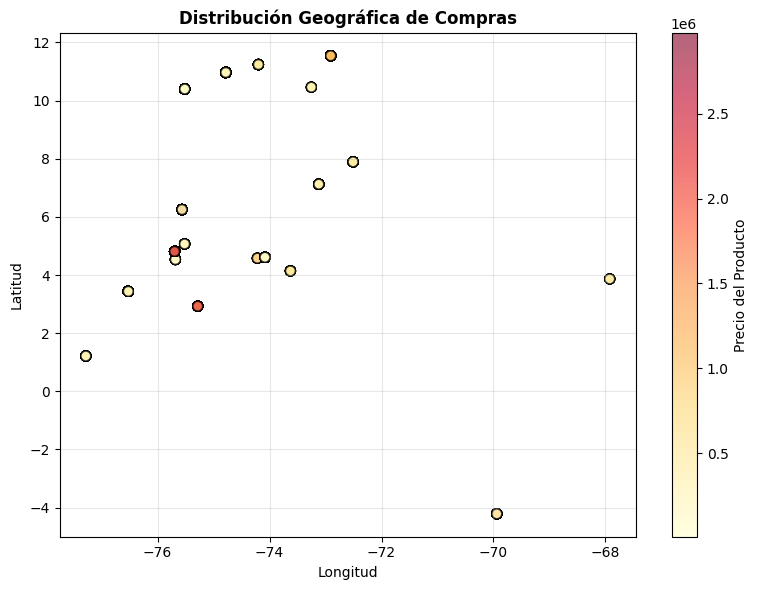

In [25]:
import matplotlib.pyplot as plt
df = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
ingresos = df.groupby('Tienda')['Precio'].sum().sort_values(ascending=False)
plt.bar(ingresos.index, ingresos.values, color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D'])
plt.title('Ingresos Totales por Tienda', fontsize=11, fontweight='bold')
plt.xlabel('Tienda')
plt.ylabel('Ingresos ($)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 3, 2)
categorias = df['Categoría del Producto'].value_counts().head(5)
plt.pie(categorias.values, labels=categorias.index, autopct='%1.1f%%', startangle=90, colors=['#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F'])
plt.title('Top 5 Categorías Más Vendidas', fontsize=11, fontweight='bold')

plt.subplot(1, 3, 3)
valoraciones = df.groupby('Tienda')['Calificación'].mean().sort_values(ascending=False)
plt.plot(valoraciones.index, valoraciones.values, marker='o', linewidth=2, color='#6C5CE7', markerfacecolor='#A29BFE')
plt.title('Calificación Promedio por Tienda', fontsize=11, fontweight='bold')
plt.xlabel('Tienda')
plt.ylabel('Calificación')
plt.ylim(0, 5)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
productos_mas_vendidos = df.groupby('Producto').size().sort_values(ascending=False).head(10)
plt.barh(productos_mas_vendidos.index[::-1], productos_mas_vendidos.values[::-1], color='#00B894')
plt.title('Top 10 Productos Más Vendidos', fontsize=12, fontweight='bold')
plt.xlabel('Cantidad de Ventas')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(df['lon'], df['lat'], c=df['Precio'], cmap='YlOrRd', alpha=0.6, s=50, edgecolors='black')
plt.colorbar(label='Precio del Producto')
plt.title('Distribución Geográfica de Compras', fontsize=12, fontweight='bold')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# **INFORME FINAL**

# Informe Final de Análisis de Datos - Tiendas E-commerce

## 1. Introducción

El propósito de este informe es presentar los resultados del análisis realizado sobre cuatro tiendas de comercio electrónico, con el objetivo de recomendar al Sr. Juan cuál representa la mejor opción para establecer una asociación comercial.

Para llegar a esta recomendación, se evaluaron cinco factores fundamentales: ingresos totales generados, categorías de productos más vendidas, calificaciones promedio de los clientes, productos con mayor y menor rotación, y costos promedio de envío. Todo el análisis se realizó utilizando Python y pandas, procesando un volumen total de transacciones equivalente a $4.403.619.200.

## 2. Desarrollo del Análisis

### 2.1 Ingresos Totales por Tienda

Al sumar los valores de la columna Precio para cada tienda, se obtuvieron los siguientes resultados:

- Tienda 1: $1.150.880.400
- Tienda 2: $1.116.343.500
- Tienda 3: $1.098.019.600
- Tienda 4: $1.038.375.700

La Tienda 1 presenta los ingresos más altos, aunque la diferencia con las demás es relativamente pequeña. El margen entre la primera y la última ubicación es de apenas un 10,8%, lo que indica que todas las tiendas manejan volúmenes de negocio comparables.

### 2.2 Categorías de Productos Más Vendidas

Un patrón consistente se observa en las cuatro tiendas: las categorías Muebles, Electrónicos y Juguetes concentran la mayor parte de las ventas.

En la categoría líder (Muebles), la Tienda 3 registra el mayor número de transacciones con 499 ventas, seguida por Tienda 4 (480), Tienda 1 (465) y Tienda 2 (442). Este dato sugiere que la Tienda 3 tiene una mayor capacidad para comercializar productos de esta categoría, que representa el principal motor de ventas del sector.

### 2.3 Calificación Promedio por Tienda

La satisfacción del cliente, medida a través de la calificación promedio, arrojó los siguientes resultados:

- Tienda 3: 4,048
- Tienda 2: 4,037
- Tienda 4: 3,996
- Tienda 1: 3,977

Aunque las diferencias numéricas parecen pequeñas, en términos de experiencia del cliente representan una brecha significativa. La Tienda 3 logra la mejor puntuación, lo que generalmente se traduce en mayor fidelización, menores tasas de devolución y mejor reputación en el mercado.

### 2.4 Productos Más y Menos Vendidos

Los productos con mayor frecuencia de venta por tienda fueron:

- Tienda 1: Armario (60 ventas)
- Tienda 2: Iniciando en programación (65 ventas)
- Tienda 3: Kit de bancas (57 ventas)
- Tienda 4: Cama box (62 ventas)

Es relevante notar que tres de los cuatro productos más vendidos pertenecen a la categoría Muebles, reforzando la importancia estratégica de esta línea de productos.

### 2.5 Costo de Envío Promedio por Tienda

El análisis del costo de envío promedio mostró:

- Tienda 4: $23.459
- Tienda 3: $24.806
- Tienda 2: $25.216
- Tienda 1: $26.019

La Tienda 1, a pesar de liderar en ingresos, aplica el costo de envío más elevado. Esto podría representar una barrera para la conversión de nuevas ventas. Por el contrario, la Tienda 3 mantiene un costo competitivo sin sacrificar la calidad del servicio.

### 2.6 Visualizaciones Generadas

Para complementar el análisis cuantitativo, se generaron cuatro visualizaciones:

1. Gráfico de barras comparando ingresos totales por tienda
2. Gráfico circular mostrando la distribución del top 5 de categorías
3. Gráfico de línea representando la calificación promedio por tienda
4. Gráfico de dispersión con la distribución geográfica de las compras

Estas visualizaciones permiten identificar de forma rápida las tendencias principales y facilitan la comunicación de los hallazgos.

## 3. Conclusión y Recomendación

### Tienda Recomendada: Tienda 3

Tras evaluar integralmente los cinco factores analizados, se recomienda al Sr. Juan establecer su asociación comercial con la Tienda 3. Esta recomendación se sustenta en los siguientes argumentos:

En primer lugar, la Tienda 3 obtiene la mejor calificación promedio de clientes (4,048 sobre 5). En el comercio electrónico, la satisfacción del cliente es un predictor clave de crecimiento sostenido, ya que impacta directamente en la retención, las recomendaciones boca a boca y la reducción de costos asociados a devoluciones o reclamos.

En segundo lugar, esta tienda lidera en la categoría más importante del portafolio: Muebles, con 499 ventas. Esto indica no solo una buena selección de productos, sino también una ejecución comercial efectiva en el segmento de mayor demanda.

En tercer lugar, su costo de envío promedio ($24.806) es el segundo más competitivo del grupo. Esto representa un equilibrio adecuado entre sostenibilidad operativa y atractivo para el cliente final.

Si bien la Tienda 3 ocupa el tercer lugar en ingresos totales, la diferencia con las tiendas líderes es marginal (4,6% menos que la Tienda 1). Considerando que cuenta con la mejor satisfacción de clientes y una posición fuerte en la categoría principal, existe un potencial claro para incrementar sus ingresos mediante estrategias de retención y expansión de portafolio.

### Consideraciones sobre las otras tiendas

La Tienda 1, aunque genera más ingresos, presenta la calificación más baja y el costo de envío más alto. Esta combinación podría indicar un enfoque en volumen a expensas de la experiencia del cliente, lo que representa un riesgo a mediano plazo.

La Tienda 2 muestra resultados equilibrados pero sin destacar en ningún factor clave, lo que limita su potencial diferenciador.

La Tienda 4, si bien tiene el envío más económico, registra los ingresos más bajos y una calificación intermedia, lo que sugiere desafíos en la generación de demanda o en la conversión.

### Impacto esperado de la asociación

Al asociarse con la Tienda 3, el Sr. Juan puede anticipar:

- Una base de clientes satisfechos con mayor probabilidad de recompra
- Ventas estables apoyadas en la categoría de mayor demanda del mercado
- Condiciones logísticas competitivas que favorecen la decisión de compra
- Un entorno de menor riesgo operativo, dada la trayectoria positiva en indicadores de calidad

## 4. Metodología

El análisis se desarrolló utilizando Python como lenguaje principal, con las librerías pandas para manipulación de datos y matplotlib para la generación de visualizaciones. Los datos provienen de cuatro archivos CSV que contienen registros de transacciones de las tiendas evaluadas. Se procesó un total consolidado de registros que representan la actividad comercial de las cuatro tiendas en el período analizado.

Las métricas evaluadas fueron calculadas mediante operaciones de agrupación y agregación estándar: suma para ingresos, conteo para frecuencia de ventas, promedio para calificaciones y costos de envío. Los resultados se validaron mediante visualizaciones que permitieron confirmar los patrones identificados en el análisis numérico.

---

Informe elaborado como parte del Challenge 1 de Data Science - Alura Latam.